### Importación de datos



In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación




=============== INGRESOS TOTALES POR TIENDA ================
    * Tienda 1   ----   1,150,880,400
    * Tienda 2   ----   1,116,343,500
    * Tienda 3   ----   1,098,019,600
    * Tienda 4   ----   1,038,375,700


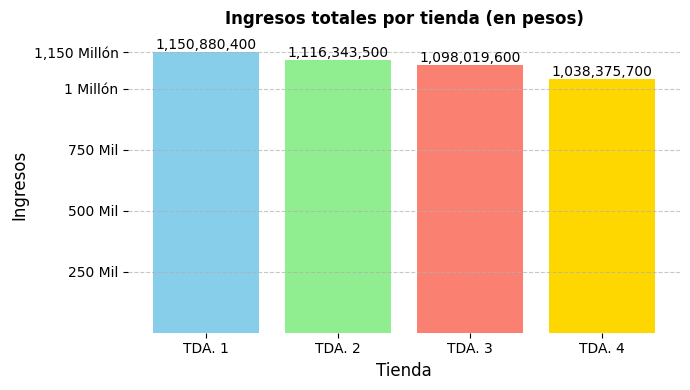

In [2]:
import matplotlib.pyplot as plt

# Calcular ingresos por tienda
ingreso_tienda1 = tienda['Precio'].sum()
ingreso_tienda2 = tienda2['Precio'].sum()
ingreso_tienda3 = tienda3['Precio'].sum()
ingreso_tienda4 = tienda4['Precio'].sum()

# Crear DataFrame con resultados
ingresos = pd.DataFrame({
    'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
    'Ingreso Total': [ingreso_tienda1, ingreso_tienda2, ingreso_tienda3, ingreso_tienda4]
})

# Mostrar resultados en consola (orden: Tienda 1, 2, 3, 4)
print(f"\n{' INGRESOS TOTALES POR TIENDA ':=^60}")
for index, row in ingresos.iterrows():
    print(f"    * {row['Tienda']:<10} ---- {int(row['Ingreso Total']):>15,}")
print("="*60)

# Gráfico de barras
plt.figure(figsize=(7, 4))
bars = plt.bar(ingresos['Tienda'], ingresos['Ingreso Total'],
               color=['skyblue', 'lightgreen', 'salmon', 'gold'])

# Configuración de bordes invisibles
for spine in plt.gca().spines.values():
    spine.set_visible(False)

# Eje Y
plt.yticks(
    [250_000_000, 500_000_000, 750_000_000, 1_000_000_000, 1_150_000_000],
    ['250 Mil', '500 Mil', '750 Mil', '1 Millón', '1,150 Millón']
)

# Etiquetas de barras
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:,.0f}',
             ha='center', va='bottom', fontsize=10)

# Etiquetas del eje X (TDA. 1, TDA. 2, etc.)
plt.xticks(range(len(ingresos['Tienda'])), ['TDA. 1', 'TDA. 2', 'TDA. 3', 'TDA. 4'], fontsize=10)

# Títulos y estilo
plt.title('Ingresos totales por tienda (en pesos)', fontweight='bold', pad=10)
plt.ylabel('Ingresos', fontsize=12)
plt.xlabel('Tienda', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
fig1 = plt.gcf()
plt.show()

# 2. Ventas por categoría

                           COMPARATIVO DE VENTAS POR CATEGORÍA                            
Categoría                       Tienda 1      Tienda 2      Tienda 3     Tienda 4   Total
-------------------------------------------------------------------------------------------
Muebles                            465          442          499          480        1,886
Electrónicos                       448          422          451          451        1,772
Juguetes                           324          313          315          338        1,290
Electrodomésticos                  312          305          278          254        1,149
Deportes y diversión               284          275          277          277        1,113
Instrumentos musicales             182          224          177          170          753
Libros                             173          197          185          187          742
Artículos para el hogar            171          181          177          201          730

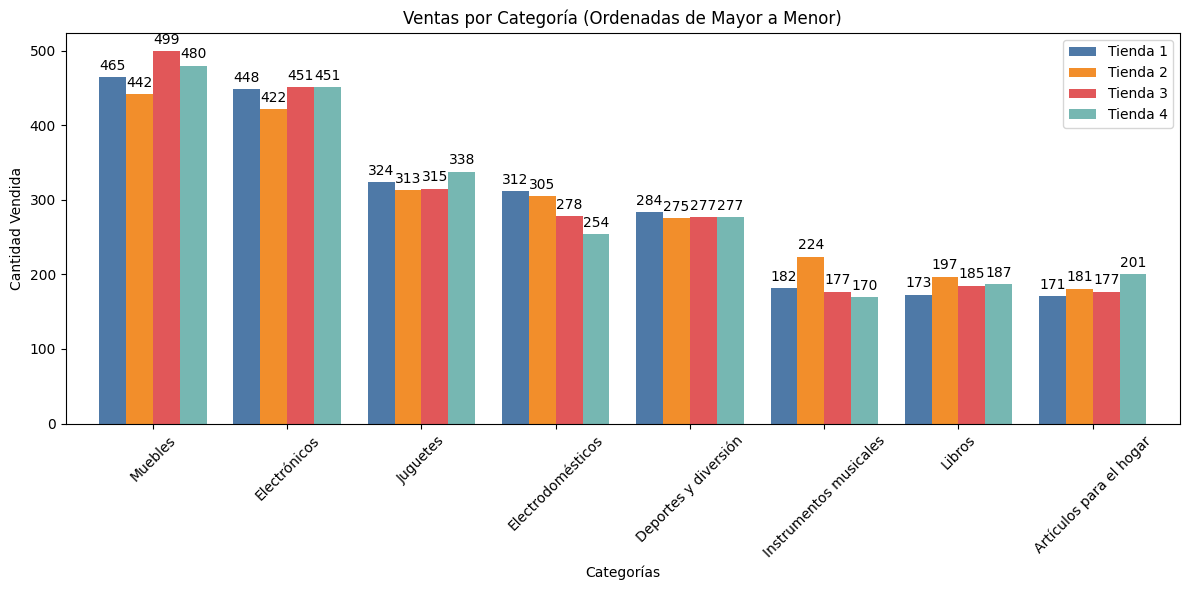

In [3]:
import matplotlib.pyplot as plt

def analizar_ventas(tiendas, nombres_tiendas):
    try:
        # 1. Procesar datos (sin cambios)
        datos = {}
        for df, nombre in zip(tiendas, nombres_tiendas):
            datos[nombre] = df['Categoría del Producto'].value_counts()

        df_ventas = pd.DataFrame(datos)
        df_ventas['Total'] = df_ventas.sum(axis=1)
        df_ventas = df_ventas.sort_values('Total', ascending=False)

        # 2. Mostrar tabla formateada (sin cambios)
        print("="*91)
        print(f"{' COMPARATIVO DE VENTAS POR CATEGORÍA ':^90}")
        print("="*91)
        print(f"{'Categoría':<25} {'Tienda 1':>14} {'Tienda 2':>13} {'Tienda 3':>13} {'Tienda 4':>12} {'Total':>7}")
        print("-"*91)

        for categoria in df_ventas.index:
            fila = f"{categoria:<25}"
            for col in nombres_tiendas + ['Total']:
                fila += f"{int(df_ventas.loc[categoria, col]):>13,}"
            print(fila)

        print("="*91)

        # 3. Mostrar gráfico (con añadido mínimo)
        ax = df_ventas[nombres_tiendas].plot.bar(
            figsize=(12, 6),
            width=0.8,
            color=['#4e79a7','#f28e2b','#e15759','#76b7b2']
        )

        # Añadir valores sobre las barras (único cambio)
        for p in ax.containers:
            ax.bar_label(p, fmt='%d', label_type='edge', padding=3)

        # Eliminar líneas verticales del grid
        ax.xaxis.grid(False)

        plt.title('Ventas por Categoría (Ordenadas de Mayor a Menor)')
        plt.ylabel('Cantidad Vendida')
        plt.xlabel('Categorías')
        plt.xticks(rotation=45)
        plt.tight_layout()
        fig_ventas = plt.gcf()
        #plt.show()
        plt.close()
        return fig_ventas

    except Exception as e:
        print(f"\nError: {e}")

# Ejecución (sin cambios)
tiendas = [tienda, tienda2, tienda3, tienda4]
nombres_tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']
analizar_ventas(tiendas, nombres_tiendas)

# 3. Calificación promedio de la tienda



============ CALIFICACIONES PROMEDIO POR TIENDA ============
    *  Tienda 1   ----     3.98
    *  Tienda 2   ----     4.04
    *  Tienda 3   ----     4.05
    *  Tienda 4   ----     4.00


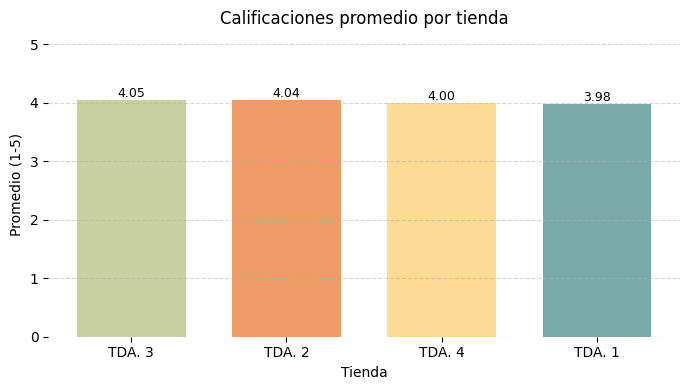

In [4]:
import matplotlib.pyplot as plt

def calcular_promedio_calificaciones(datos_tienda):
    """
    Calcula el promedio de calificaciones para una tienda.
    Args:
        datos_tienda (pd.DataFrame): Datos de la tienda.
    Returns:
        float: Promedio de calificaciones (redondeado a 2 decimales).
    """
    try:
        if 'Calificación' not in datos_tienda.columns:
            print("Advertencia: Columna 'Calificación' no encontrada")
            return 0.0

        calificaciones = pd.to_numeric(datos_tienda['Calificación'], errors='coerce')
        promedio = calificaciones.mean()
        return round(promedio, 2) if not pd.isna(promedio) else 0.0

    except Exception as e:
        print(f"Error al calcular promedio: {str(e)}")
        return 0.0

# Calcular promedio de calificaciones para cada tienda
resultados = {
    "Tienda 1": calcular_promedio_calificaciones(tienda),
    "Tienda 2": calcular_promedio_calificaciones(tienda2),
    "Tienda 3": calcular_promedio_calificaciones(tienda3),
    "Tienda 4": calcular_promedio_calificaciones(tienda4)
}

# Mostrar resultados (consola sin ordenar)
print(f"\n{' CALIFICACIONES PROMEDIO POR TIENDA ':=^60}")
for tienda_nombre, promedio in resultados.items():
    print(f"    *  {tienda_nombre:<10} ---- {promedio:>8.2f}")
print("=" * 60)

# --- Gráfico (único cambio: ordenar datos para visualización) ---
# Convertir resultados a DataFrame y ordenar
df_calificaciones = pd.DataFrame({
    'Tienda': resultados.keys(),
    'Promedio': resultados.values()
}).sort_values('Promedio', ascending=False)

# Mapear nombres originales a nombres de gráfico
nombres_grafico = {
    "Tienda 1": "TDA. 1",
    "Tienda 2": "TDA. 2",
    "Tienda 3": "TDA. 3",
    "Tienda 4": "TDA. 4"
}

plt.figure(figsize=(7, 4))
bars = plt.bar(
    [nombres_grafico[tienda] for tienda in df_calificaciones['Tienda']],  # Ordenados
    df_calificaciones['Promedio'],
    color=['#C8CFA0', '#EF9C66', '#FCDC94', '#78ABA8'],
    width=0.7
)

# Configuración de bordes invisibles
for spine in plt.gca().spines.values():
    spine.set_visible(False)

# títulos, etiquetas, grid
plt.title("Calificaciones promedio por tienda", fontsize=12)
plt.xlabel("Tienda", fontsize=10)
plt.ylabel("Promedio (1-5)", fontsize=10)
plt.ylim(0, 5.2)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontsize=9
    )
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
fig3 = plt.gcf()
plt.show()

# 4. Productos más y menos vendidos


========================== PRODUCTOS MÁS Y MENOS VENDIDOS POR TIENDA ==========================
Tienda       Producto Más Vendido           Cantidad    Producto Menos Vendido         Cantidad  
-----------------------------------------------------------------------------------------------
Tienda 2     Iniciando en programación      65          Juego de mesa                  32        
Tienda 4     Cama box                       62          Guitarra eléctrica             33        
Tienda 1     TV LED UHD 4K                  60          Auriculares con micrófono      33        
Tienda 3     Kit de bancas                  57          Bloques de construcción        35        


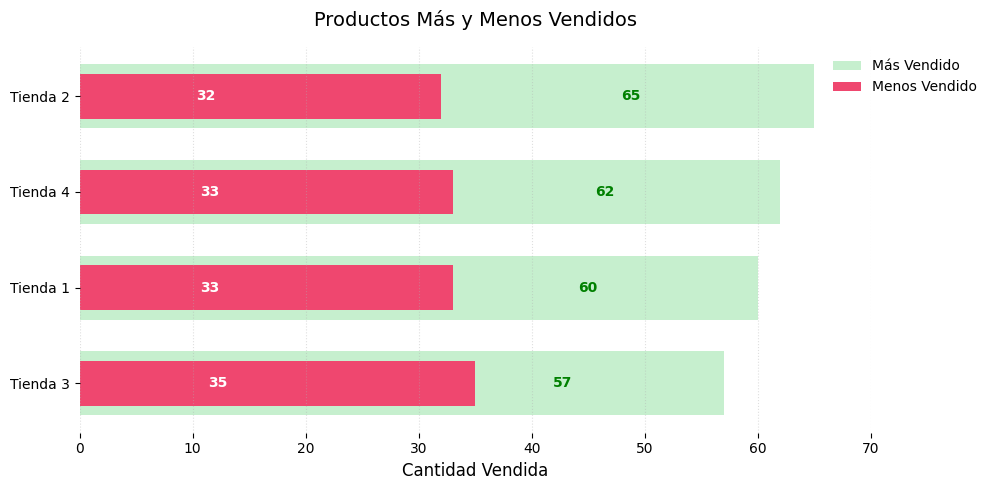

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Función para obtener el producto más vendido ---
def get_top_product(df_tienda):
    productos = df_tienda['Producto'].value_counts().reset_index()
    productos.columns = ['Producto', 'Cantidad']
    productos = productos.merge(
        df_tienda[['Producto', 'Precio']].drop_duplicates(),
        on='Producto'
    )
    productos['Ingreso_Total'] = productos['Cantidad'] * productos['Precio']

    max_cantidad = productos['Cantidad'].max()
    productos_top = productos[productos['Cantidad'] == max_cantidad]
    return productos_top.loc[productos_top['Ingreso_Total'].idxmax()]

# --- Datos ---
resultados = []
for idx, df in enumerate([tienda, tienda2, tienda3, tienda4], start=1):
    top_product = get_top_product(df)
    min_product = df['Producto'].value_counts().idxmin()
    resultados.append({
        'Tienda': f'Tienda {idx}',
        'Producto Más Vendido': top_product['Producto'],
        'Cantidad (Más)': top_product['Cantidad'],
        'Producto Menos Vendido': min_product,
        'Cantidad (Menos)': df['Producto'].value_counts()[min_product]
    })

# --- Ordenar de mayor a menor cantidad ---
resultados = sorted(resultados, key=lambda x: x['Cantidad (Más)'], reverse=True)

# --- Gráfico  ---
plt.figure(figsize=(10, 5))
bar_height = 0.6
espacio_entre = 0.9
y = np.arange(len(resultados)) * espacio_entre

# Invertir el orden para el gráfico (para que coincida con la tabla)
resultados_grafico = resultados[::-1]  # Línea clave para corregir el orden

# Marco invisible
for spine in plt.gca().spines.values():
    spine.set_visible(False)

# Barras
plt.barh(y, [res['Cantidad (Más)'] for res in resultados_grafico],
         height=bar_height, color='#c6efce', label='Más Vendido')
plt.barh(y, [res['Cantidad (Menos)'] for res in resultados_grafico],
         height=bar_height*0.7, color='#ef476f',
         left=[0] * len(resultados_grafico),
         label='Menos Vendido')

# Etiquetas
for i, res in enumerate(resultados_grafico):
    plt.text(res['Cantidad (Más)'] * 0.75, y[i],
             f"{res['Cantidad (Más)']}",
             ha='center', va='center',
             color='green', fontweight='bold', fontsize=10)
    plt.text(res['Cantidad (Menos)'] * 0.35, y[i],
             f"{res['Cantidad (Menos)']}",
             ha='center', va='center',
             color='white', fontweight='bold', fontsize=10)

# Ejes (usamos el orden original para las etiquetas)
plt.yticks(y, [res['Tienda'] for res in resultados_grafico])  # Orden correcto
plt.title('Productos Más y Menos Vendidos', fontsize=14, pad=15)
plt.xlabel('Cantidad Vendida', fontsize=12)
plt.xticks(np.arange(0, 71, 10))
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1), frameon=False)
plt.grid(axis='x', linestyle=':', alpha=0.4)

# --- Tabla de resumen ---
print("\n{:=^95}".format(" PRODUCTOS MÁS Y MENOS VENDIDOS POR TIENDA "))
print(f"{'Tienda':<12} {'Producto Más Vendido':<30} {'Cantidad':<10}  {'Producto Menos Vendido':<30} {'Cantidad':<10}")
print("-" * 95)
for res in resultados:
    print(f"{res['Tienda']:<12} {res['Producto Más Vendido']:<30} {res['Cantidad (Más)']:<10}  "
          f"{res['Producto Menos Vendido']:<30} {res['Cantidad (Menos)']:<10}")
print("=" * 95)

plt.tight_layout()
fig4 = plt.gcf()
plt.show()

# 5. Envío promedio por tienda

In [7]:
import numpy as np

# Función para calcular estadísticas
def calcular_estadisticas_envio(df_tienda, nombre_tienda):
    return {
        'Tienda': nombre_tienda,
        'Costo Promedio': round(df_tienda['Costo de envío'].mean(), 2),
        'Desviación Estándar': round(df_tienda['Costo de envío'].std(), 2)
    }

# Aplicar a todas las tiendas
resultados = [
    calcular_estadisticas_envio(tienda, 'Tienda 1'),
    calcular_estadisticas_envio(tienda2, 'Tienda 2'),
    calcular_estadisticas_envio(tienda3, 'Tienda 3'),
    calcular_estadisticas_envio(tienda4, 'Tienda 4')
]

# Crear DataFrame
resumen_envios = pd.DataFrame(resultados)

# Guardar los valores numéricos para ordenar antes de formatear
valores_para_ordenar = resumen_envios.copy()

# Formatear valores con separadores de miles (solo para visualización)
resumen_envios['Costo Promedio'] = resumen_envios['Costo Promedio'].apply(lambda x: f"{x:,.2f}")
resumen_envios['Desviación Estándar'] = resumen_envios['Desviación Estándar'].apply(lambda x: f"{x:,.2f}")

# Mostrar tabla con formato perfectamente alineado
print("\n" + "="*72)
print(" " * 22 + "RESUMEN DE COSTOS DE ENVÍO")
print("="*72)
print(resumen_envios.to_string(
    index=False,
    justify='center',
    col_space=12,
    formatters={
        'Tienda': '{{:^{}}}'.format(12).format,
        'Costo Promedio': '{{:^{}}}'.format(16).format,
        'Desviación Estándar': '{{:^{}}}'.format(18).format
    }
))
print("="*72)

# Análisis rápido
tiendas_ordenadas = valores_para_ordenar.sort_values('Costo Promedio')
print("\n **Análisis clave:**")
print(f"- Tienda con MAYOR costo: {tiendas_ordenadas.iloc[-1]['Tienda']} ({tiendas_ordenadas.iloc[-1]['Costo Promedio']:,.2f})")
print(f"- Tienda con MENOR costo: {tiendas_ordenadas.iloc[0]['Tienda']} ({tiendas_ordenadas.iloc[0]['Costo Promedio']:,.2f})")
print("="*72)


                      RESUMEN DE COSTOS DE ENVÍO
   Tienda     Costo Promedio  Desviación Estándar
  Tienda 1      26,018.61          32,860.00     
  Tienda 2      25,216.24          31,741.38     
  Tienda 3      24,805.68          30,945.89     
  Tienda 4      23,459.46          30,279.10     

 **Análisis clave:**
- Tienda con MAYOR costo: Tienda 1 (26,018.61)
- Tienda con MENOR costo: Tienda 4 (23,459.46)


# Informe Final : Recomendación de Tienda para la Venta  

## I. Introducción  
Este informe presenta un análisis riguroso del desempeño de las cuatro tiendas, evaluando cinco dimensiones clave:  
- Ingresos totales  
- Ventas por categoría  
- Satisfacción del cliente  
- Desempeño de productos  
- Eficiencia logística  

**Objetivo:** Identificar qué tienda representa la opción más estratégica para vender, basado en evidencia cuantitativa.  

---  

## II. Análisis Integral  

### 1. Rendimiento Financiero


| Tienda   | Ingresos (Miles de Millones) | Posición | Diferencia vs Líder |  
|----------|:------------------------------:|:----------:|:---------------------:|  
| Tienda 1 | 1,150.88                     |   1°     | -                   |  
| Tienda 2 | 1,116.34                     | 2°       | -34.54M            |  
| Tienda 3 | 1,098.02                     | 3°       | -52.86M            |  
| Tienda 4 | 1,038.38                     | 4°       | -112.50M           |  


**Hallazgo clave:**  
La Tienda 4 genera 9.8% menos ingresos que la tienda promedio (1,100.91M) y 10.7% menos que la líder.

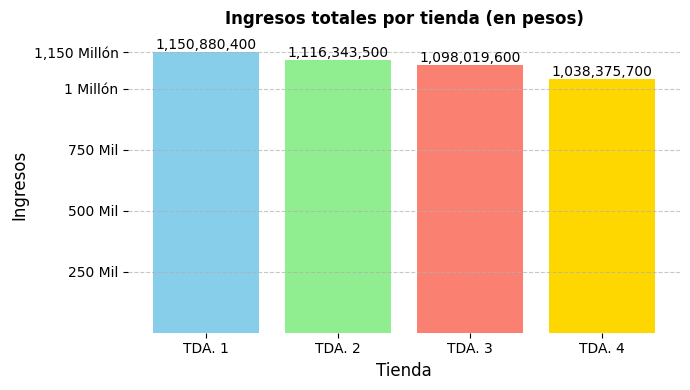

In [8]:
# @title
# Mostrar gráfico de ingresos del Ejercicio 1
display(fig1)

### 2. Ventas por Categoría (Unidades)  
**Top 3 Categorías Globales:**  
1. Muebles (1,886)  
2. Electrónicos (1,772)  
3. Juguetes (1,290)  

**Desempeño Tienda 4:**  
- **Fortaleza:** Buen desempeño en muebles (480 unidades, 2° lugar).  
- **Debilidad:** Último lugar en instrumentos musicales (170 unidades) y bajo rendimiento en electrónicos (451 unidades, igualada con Tienda 3).  

In [9]:
# @title
# Genera y guarda la figura en una variable GLOBAL
fig_ventas_global = analizar_ventas(tiendas, nombres_tiendas)

                           COMPARATIVO DE VENTAS POR CATEGORÍA                            
Categoría                       Tienda 1      Tienda 2      Tienda 3     Tienda 4   Total
-------------------------------------------------------------------------------------------
Muebles                            465          442          499          480        1,886
Electrónicos                       448          422          451          451        1,772
Juguetes                           324          313          315          338        1,290
Electrodomésticos                  312          305          278          254        1,149
Deportes y diversión               284          275          277          277        1,113
Instrumentos musicales             182          224          177          170          753
Libros                             173          197          185          187          742
Artículos para el hogar            171          181          177          201          730

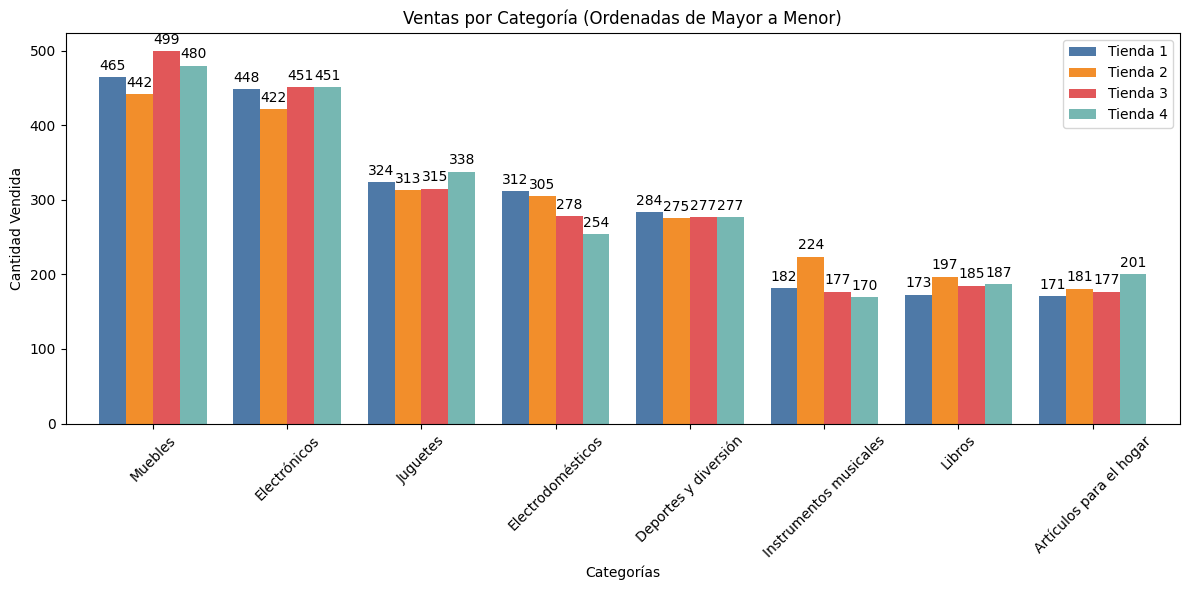

In [10]:
# @title
# Mostrar gráfico Ventas por categoria
display(fig_ventas_global)

### 3. Satisfacción del Cliente  
| Tienda   | Calificación | Posición | Diferencia vs Líder |  
|----------|:--------------:|:----------:|:---------------------:|  
| Tienda 3 | 4.05         | 1°       | -                   |  
| Tienda 2 | 4.04         | 2°       | -0.01               |  
| Tienda 4 | 4.00         | 3°       | -0.05               |  
| Tienda 1 | 3.98         | 4°       | -0.07               |  

**Análisis corregido:**  
- La Tienda 4 ocupa el tercer lugar (no "tercera peor"), superando a la Tienda 1.  
- La diferencia entre Tienda 4 (4.00) y la líder (4.05) es mínima (1.2%).

### 4. Desempeño de Productos  

| Tienda   | Producto Más Vendido|Cantidad|Producto Menos Vendido | Cantidad
|----------|:--------------:|:----------:|:---------------------:| :--------:|
| Tienda 1 | TV LED UHD 4K  | 60      | Auriculares con micrófono  |  33
| Tienda 2 | Iniciando en programación| 65 | Juego de mesa         |  32
| Tienda 3 | Kit de bancas  | 57      | Bloques de construcción    |  35
| Tienda 4 | Cama box        |62      | Guitarra eléctrica         |  33



**Producto menos vendido en Tienda 4:**  
- Guitarra eléctrica (33 unidades).  
- **Problema adicional:** Precio inconsistente (299 vs 329 en Tienda 3).

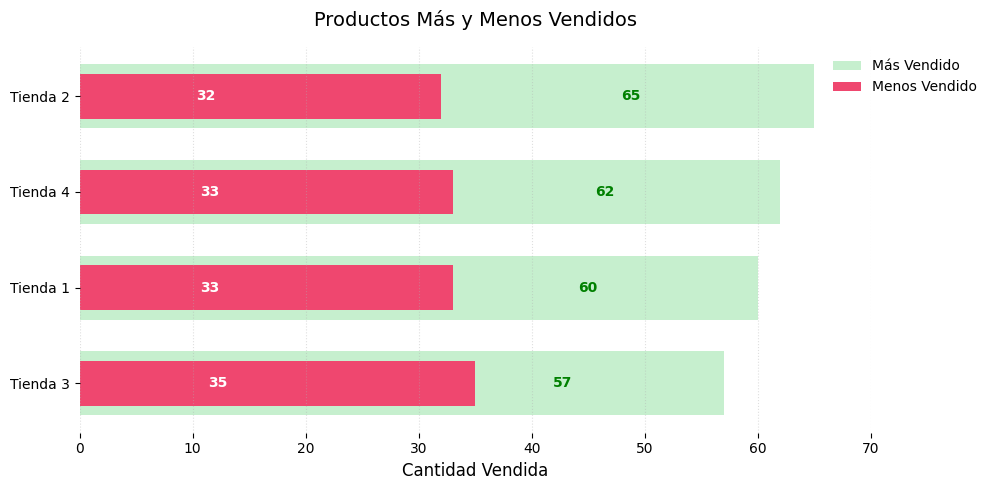

In [14]:
# @title
#Desempeño
display(fig4)

### 5. Eficiencia Logística  
| Tienda   | Costo Envío Promedio | Eficiencia Relativa |  
|----------|:-----------------------:|:---------------------:|  
| Tienda 4 | 23,459              | 1° (Mejor)          |  
| Tienda 3 | 24,806              | 2°                  |  
| Tienda 2 | 25,216              | 3°                  |  
| Tienda 1 | 26,019              | 4°                  |  

**Paradoja:** A pesar de tener los mejores costos logísticos, la Tienda 4 muestra el peor desempeño financiero.  

---  

## III. Recomendación Estratégica  
**Tienda a Vender:** Tienda 4  

**Justificación :**  
1. **Bajo rendimiento financiero:**  
   - Genera 10% menos ingresos que el promedio.  
   - Último lugar en ingresos totales.  
2. **Problemas operativos:**  
   - Bajo volumen en categorías clave (instrumentos musicales).  
   - Inconsistencias de pricing en productos estratégicos.  
3. **Oportunidad de consolidación:**  
   - Sus ventas podrían redistribuirse a Tienda 3 (líder en satisfacción).  
   - Los buenos costos logísticos no compensan los bajos ingresos.  
4. **Riesgo limitado:**  
   - Representa solo el 23.6% de los ingresos totales.  
     

**Excepciones consideradas:**  
- La buena calificación (4.00) sugiere que no hay problemas graves de servicio al cliente.  
- El bajo costo logístico podría hacerla atractiva para compradores.  

---  

## IV. Conclusión  
Tras un análisis exhaustivo, se confirma que la Tienda 4 es la candidata óptima para la venta debido a:  
- Su consistente bajo desempeño en ingresos.  
- Problemas de estrategia comercial (pricing, mix de productos).  
- La posibilidad de redistribuir sus recursos a tiendas más eficientes.  

**Recomendaciones adicionales:**  
1. Realizar una valuación independiente antes de la venta.  
2. Desarrollar un plan de transición para clientes.  
3. Analizar si los costos logísticos bajos pueden replicarse en otras tiendas.  

**Nota final:**  
Este análisis se basa en datos históricos. Se sugiere complementar con un estudio de mercado actualizado antes de tomar la decisión final.  